# Forest Fire & Smoke Detection — CNN Image Classification
**Phase 3: Proposal & Code Implementation**

Author: Tarun Mikkilineni · Matriculation ID: 81689998

This notebook builds a **CNN-based image-classification** pipeline that distinguishes
**fire**, **smoke** and **neutral** scenes. The dataset is published in YOLO
(object-detection) format, so the first stage converts the bounding-box annotations
into image-level classification labels. We then train a **custom CNN from scratch**
and a **MobileNetV2 transfer-learning model**, and compare them using a confusion
matrix, classification report, accuracy/loss curves, ROC curves and Grad-CAM.

**Dataset:** https://www.kaggle.com/datasets/sayedgamal99/smoke-fire-detection-yolo

> Add the dataset to the notebook via **Add Input → Datasets** before running.
> Enable a **GPU accelerator** (Settings → Accelerator → GPU) for faster training.

## 1. Imports and reproducibility setup

In [1]:
import os, glob, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# Create an output folder so every figure/model is saved for the GitHub repo
OUT_DIR = "/kaggle/working/outputs"
os.makedirs(OUT_DIR, exist_ok=True)

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

2026-06-28 16:12:13.971031: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782663134.157774      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782663134.210077      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782663134.653344      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782663134.653385      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782663134.653387      58 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Locate the dataset

The Kaggle dataset is mounted read-only under `/kaggle/input/`. The exact folder name
can vary, so we search for it automatically and read `data.yaml` (if present) to get the
object-class names used in the YOLO annotations.

In [2]:
# --- Find the dataset root robustly -------------------------------------------------
SEARCH_ROOT = "/kaggle/input"
candidates = glob.glob(os.path.join(SEARCH_ROOT, "*smoke*fire*")) + \
             glob.glob(os.path.join(SEARCH_ROOT, "*fire*smoke*")) + \
             glob.glob(os.path.join(SEARCH_ROOT, "*"))
DATA_ROOT = None
for c in candidates:
    if os.path.isdir(c):
        DATA_ROOT = c
        break
assert DATA_ROOT is not None, "Dataset not found - add it via 'Add Input'."
print("Dataset root:", DATA_ROOT)

# --- Read YOLO class names from data.yaml if available ------------------------------
yaml_paths = glob.glob(os.path.join(DATA_ROOT, "**", "*.yaml"), recursive=True)
yolo_names = {0: "smoke", 1: "fire"}   # D-Fire YOLO order; data.yaml (read below) overrides this
if yaml_paths:
    txt = open(yaml_paths[0]).read()
    print("\nFound data.yaml:\n", txt[:400])
    # crude parse of a "names: [fire, smoke]" or "names:\n  0: fire" style block
    import re
    inline = re.search(r"names\s*:\s*\[(.*?)\]", txt, re.S)
    if inline:
        items = [x.strip().strip("'\"") for x in inline.group(1).split(",")]
        yolo_names = {i: n for i, n in enumerate(items) if n}
print("\nYOLO object classes:", yolo_names)

Dataset root: /kaggle/input/datasets

Found data.yaml:
 path: /kaggle/working/D Fire Dataset  # dataset root dir
train: data/train/images  # train images (relative to 'path')
val: data/val/images  # val images (relative to 'path')
test: data/test/images  # test images (relative to 'path')

# Classes
names: ['smoke', 'fire']  # Replace with your actual class names

# Counts
nc: 2  # number of classes
train_count: 14122
val_count: 3099
test_count: 4306


YOLO object classes: {0: 'smoke', 1: 'fire'}


## 3. Convert YOLO annotations into classification labels

YOLO label files contain one line per object: `class_id  x  y  w  h`. For an
image-classification task we need **one label per image**. We apply a clear,
documented rule based on which object classes appear in each image:

* an image containing any **fire** box → **`fire`**
* otherwise, an image containing any **smoke** box → **`smoke`**
* an image with an empty / missing label file → **`neutral`** (no fire or smoke)

`fire` is given priority over `smoke` because a visible flame is the more critical
event to detect. This produces a single-label, multi-class problem suitable for a
confusion matrix and classification report.

In [3]:
def find_pairs(root):
    """Return (image_path, label_path-or-None) for every image in the dataset."""
    img_ext = (".jpg", ".jpeg", ".png", ".bmp")
    images = [p for p in glob.glob(os.path.join(root, "**", "*"), recursive=True)
              if p.lower().endswith(img_ext)]
    pairs = []
    for img in images:
        # YOLO stores labels in a sibling 'labels' folder mirroring 'images'
        lbl = img.replace(os.sep + "images" + os.sep, os.sep + "labels" + os.sep)
        lbl = os.path.splitext(lbl)[0] + ".txt"
        pairs.append((img, lbl if os.path.exists(lbl) else None))
    return pairs

def derive_label(label_path):
    """Map a YOLO label file to a single classification label."""
    if label_path is None:
        return "neutral"
    class_ids = set()
    with open(label_path) as f:
        for line in f:
            line = line.strip()
            if line:
                class_ids.add(int(float(line.split()[0])))
    has_fire  = any(yolo_names.get(c, "").lower() == "fire"  for c in class_ids)
    has_smoke = any(yolo_names.get(c, "").lower() == "smoke" for c in class_ids)
    if has_fire:
        return "fire"
    if has_smoke:
        return "smoke"
    return "neutral"

pairs = find_pairs(DATA_ROOT)
df = pd.DataFrame({"image": [p[0] for p in pairs]})
df["label"] = [derive_label(p[1]) for p in pairs]

# Drop any class with too few samples to split safely
counts = df["label"].value_counts()
df = df[df["label"].isin(counts[counts >= 10].index)].reset_index(drop=True)

CLASSES = sorted(df["label"].unique())
NUM_CLASSES = len(CLASSES)
class_to_idx = {c: i for i, c in enumerate(CLASSES)}
df["y"] = df["label"].map(class_to_idx)

print("Total images:", len(df))
print("Classes:", CLASSES)
print(df["label"].value_counts())

Total images: 21527
Classes: ['fire', 'neutral', 'smoke']
label
neutral    9838
smoke      5867
fire       5822
Name: count, dtype: int64


## 4. Exploratory data analysis

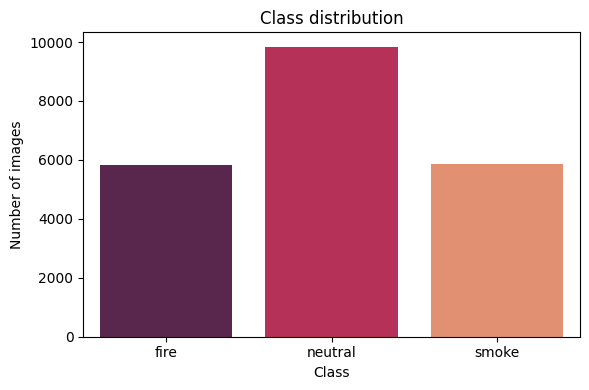

I0000 00:00:1782663368.063653      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


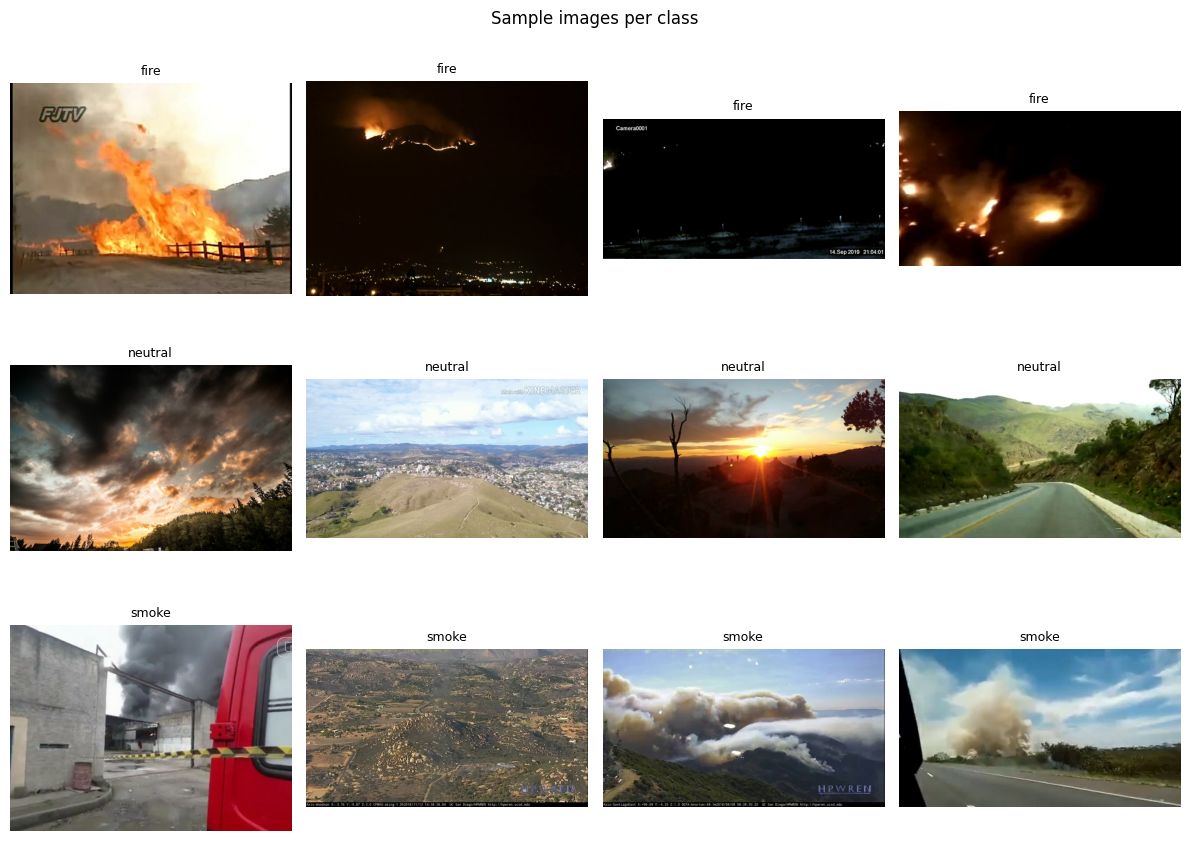

In [4]:
# --- Class distribution -------------------------------------------------------------
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="label", order=CLASSES, palette="rocket")
plt.title("Class distribution"); plt.xlabel("Class"); plt.ylabel("Number of images")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/class_distribution.png", dpi=150); plt.show()

# --- Sample images per class --------------------------------------------------------
fig, axes = plt.subplots(NUM_CLASSES, 4, figsize=(12, 3 * NUM_CLASSES))
axes = np.atleast_2d(axes)
for r, cls in enumerate(CLASSES):
    samples = df[df.label == cls].sample(min(4, (df.label == cls).sum()), random_state=SEED)
    for c, (_, row) in enumerate(samples.iterrows()):
        img = tf.io.decode_image(tf.io.read_file(row["image"]), channels=3).numpy()
        axes[r, c].imshow(img); axes[r, c].axis("off")
        if c == 0: axes[r, c].set_ylabel(cls, fontsize=12)
        axes[r, c].set_title(cls, fontsize=9)
plt.suptitle("Sample images per class"); plt.tight_layout()
plt.savefig(f"{OUT_DIR}/sample_images.png", dpi=150); plt.show()

## 5. Train / validation / test split

A **stratified 70 / 15 / 15** split keeps the class proportions identical across the
three sets, which is important given the class imbalance shown above.

In [5]:
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df["y"],
                                     random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["y"],
                                   random_state=SEED)
print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")

Train: 15068  Val: 3229  Test: 3230


## 6. Input pipeline — resizing, normalization and augmentation

Every image is decoded, resized to **224×224** and scaled to `[0, 1]`. Data
**augmentation** (random flips, rotation, zoom and contrast) is applied to the
**training set only** to improve generalisation and reduce over-fitting.

In [6]:
IMG_SIZE = (224, 224)
BATCH = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_image(path, label):
    img = tf.io.decode_image(tf.io.read_file(path), channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0          # normalize to [0,1]
    return img, label

augmenter = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="augmentation")

def make_ds(frame, training=False):
    ds = tf.data.Dataset.from_tensor_slices((frame["image"].values, frame["y"].values))
    if training:
        ds = ds.shuffle(len(frame), seed=SEED)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(lambda x, y: (augmenter(x, training=True), y),
                    num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH).prefetch(AUTOTUNE)

train_ds = make_ds(train_df, training=True)
val_ds   = make_ds(val_df)
test_ds  = make_ds(test_df)

# Class weights to counter imbalance
from sklearn.utils.class_weight import compute_class_weight
cw = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=train_df["y"].values)
class_weight = {i: w for i, w in enumerate(cw)}
print("Class weights:", class_weight)

Class weights: {0: np.float64(1.232556237218814), 1: np.float64(0.7294026527253364), 2: np.float64(1.222952682412142)}


## 7. Model A — Custom CNN built from scratch

Four convolutional blocks (Conv → BatchNorm → ReLU → MaxPool) with increasing filter
depth, followed by global average pooling, a dense layer with dropout, and a softmax
output. Batch normalisation stabilises training and dropout reduces over-fitting.

In [7]:
def build_custom_cnn():
    m = models.Sequential(name="Custom_CNN")
    m.add(layers.Input(shape=IMG_SIZE + (3,)))
    for f in [32, 64, 128, 256]:
        m.add(layers.Conv2D(f, 3, padding="same", use_bias=False))
        m.add(layers.BatchNormalization())
        m.add(layers.Activation("relu"))
        m.add(layers.MaxPooling2D())
    m.add(layers.GlobalAveragePooling2D())
    m.add(layers.Dense(128, activation="relu"))
    m.add(layers.Dropout(0.4))
    m.add(layers.Dense(NUM_CLASSES, activation="softmax"))
    return m

cnn = build_custom_cnn()
cnn.compile(optimizer=optimizers.Adam(1e-3),
            loss="sparse_categorical_crossentropy", metrics=["accuracy"])
cnn.summary()

Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,139 (1.61 MB)

 Trainable params: 422,179 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [9]:
EPOCHS = 25
cb = [callbacks.EarlyStopping(patience=5, restore_best_weights=True,
                             monitor="val_accuracy"),
      callbacks.ReduceLROnPlateau(patience=3, factor=0.5, monitor="val_loss")]

hist_cnn = cnn.fit(train_ds, validation_data=val_ds, epochs=EPOCHS,
                   class_weight=class_weight, callbacks=cb, verbose=1)

Epoch 1/25
471/471 ━━━━━━━━━━━━━━━━━━━━ 127s 269ms/step - accuracy: 0.5834 - loss: 0.8238 - val_accuracy: 0.6110 - val_loss: 0.8176 - learning_rate: 0.0010
Epoch 2/25
471/471 ━━━━━━━━━━━━━━━━━━━━ 98s 207ms/step - accuracy: 0.6099 - loss: 0.7691 - val_accuracy: 0.6343 - val_loss: 0.8363 - learning_rate: 0.0010
Epoch 3/25
471/471 ━━━━━━━━━━━━━━━━━━━━ 98s 208ms/step - accuracy: 0.6357 - loss: 0.7320 - val_accuracy: 0.5382 - val_loss: 1.6483 - learning_rate: 0.0010
Epoch 4/25
471/471 ━━━━━━━━━━━━━━━━━━━━ 99s 209ms/step - accuracy: 0.6486 - loss: 0.7032 - val_accuracy: 0.6163 - val_loss: 0.8224 - learning_rate: 0.0010
Epoch 5/25
471/471 ━━━━━━━━━━━━━━━━━━━━ 98s 209ms/step - accuracy: 0.6752 - loss: 0.6580 - val_accuracy: 0.6507 - val_loss: 0.7028 - learning_rate: 5.0000e-04
Epoch 6/25
471/471 ━━━━━━━━━━━━━━━━━━━━ 99s 210ms/step - accuracy: 0.6801 - loss: 0.6442 - val_accuracy: 0.7042 - val_loss: 0.7092 - learning_rate: 5.0000e-04
Epoch 7/25
471/471 ━━━━━━━━━━━━━━━━━━━━ 99s 209ms/step - accu

## 8. Model B — MobileNetV2 transfer learning

MobileNetV2 pre-trained on ImageNet is used as a frozen feature extractor with a new
classification head. Transfer learning lets us reuse rich visual features learned from
millions of images, which usually beats a from-scratch CNN on a modest dataset.

In [10]:
def build_transfer():
    base = MobileNetV2(input_shape=IMG_SIZE + (3,), include_top=False, weights="imagenet")
    base.trainable = False
    inp = layers.Input(shape=IMG_SIZE + (3,))
    x = layers.Rescaling(255.0)(inp)          # undo the /255 then apply MobileNet preproc
    x = preprocess_input(x)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    return models.Model(inp, out, name="MobileNetV2_TL")

tl = build_transfer()
tl.compile(optimizer=optimizers.Adam(1e-3),
           loss="sparse_categorical_crossentropy", metrics=["accuracy"])

hist_tl = tl.fit(train_ds, validation_data=val_ds, epochs=EPOCHS,
                 class_weight=class_weight, callbacks=cb, verbose=1)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/25
471/471 ━━━━━━━━━━━━━━━━━━━━ 116s 222ms/step - accuracy: 0.6556 - loss: 0.7211 - val_accuracy: 0.7228 - val_loss: 0.6102 - learning_rate: 0.0010
Epoch 2/25
471/471 ━━━━━━━━━━━━━━━━━━━━ 89s 189ms/step - accuracy: 0.7266 - loss: 0.5980 - val_accuracy: 0.7854 - val_loss: 0.5166 - learning_rate: 0.0010
Epoch 3/25
471/471 ━━━━━━━━━━━━━━━━━━━━ 90s 190ms/step - accuracy: 0.7383 - loss: 0.5703 - val_accuracy: 0.7795 - val_loss: 0.5194 - learning_rate: 0.0010
Epoch 4/25
471/471 ━━━━━━━━━━━━━━━━━━━━ 142s 191ms/step - accuracy: 0.7495 - loss: 0.5522 - val_accuracy: 0.7488 - val_loss: 0.5741 - learning_rate: 5.0000e-04
Epoch 5/25
471/471 ━━━━━━━━━━━━━━━━━━━━ 93s 198ms/step - accuracy: 0.7531 - loss: 0.5406 - val_accuracy: 0.7814 - val_loss: 0.5224 - learning_rate: 5.0000e-04


## 9. Evaluation

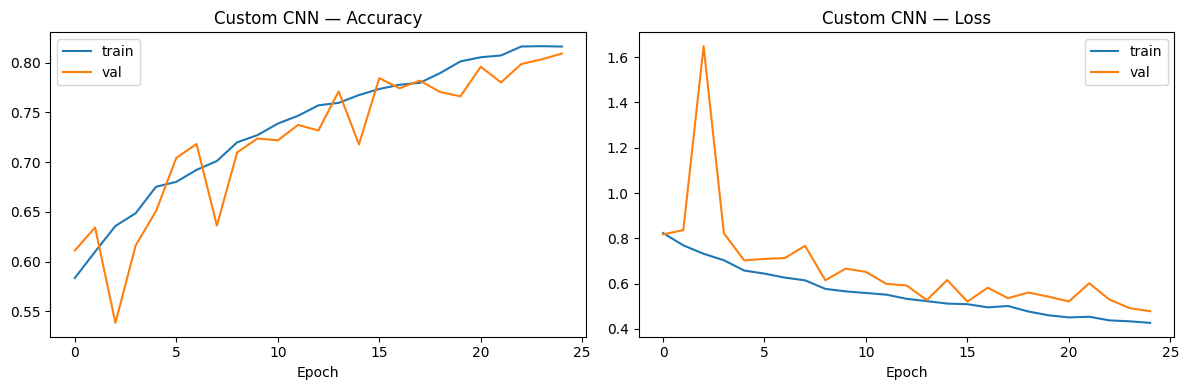

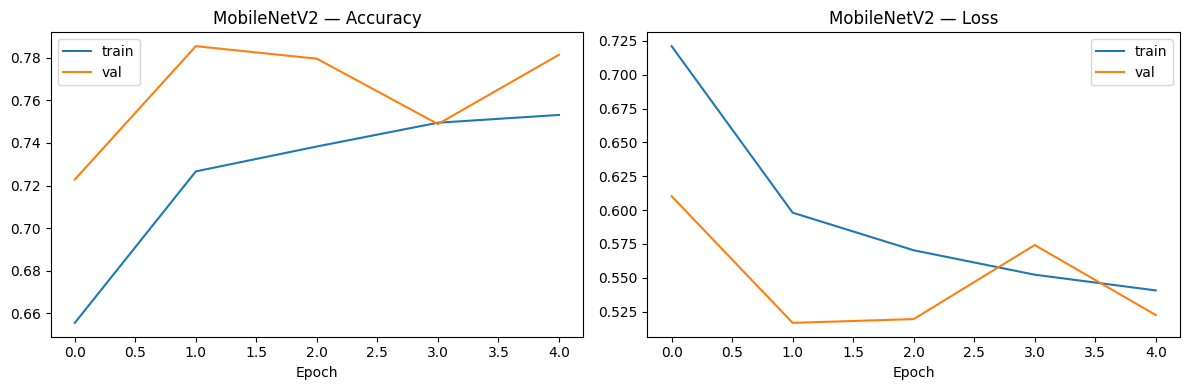

In [11]:
def plot_history(hist, title, fname):
    h = hist.history
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(h["accuracy"], label="train"); ax[0].plot(h["val_accuracy"], label="val")
    ax[0].set_title(f"{title} — Accuracy"); ax[0].set_xlabel("Epoch"); ax[0].legend()
    ax[1].plot(h["loss"], label="train"); ax[1].plot(h["val_loss"], label="val")
    ax[1].set_title(f"{title} — Loss"); ax[1].set_xlabel("Epoch"); ax[1].legend()
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/{fname}", dpi=150); plt.show()

plot_history(hist_cnn, "Custom CNN", "curves_custom_cnn.png")
plot_history(hist_tl,  "MobileNetV2", "curves_mobilenet.png")


===== Custom_CNN — Classification report =====
              precision    recall  f1-score   support

        fire      0.885     0.884     0.885       874
     neutral      0.853     0.852     0.852      1476
       smoke      0.712     0.715     0.714       880

    accuracy                          0.823      3230
   macro avg      0.817     0.817     0.817      3230
weighted avg      0.823     0.823     0.823      3230



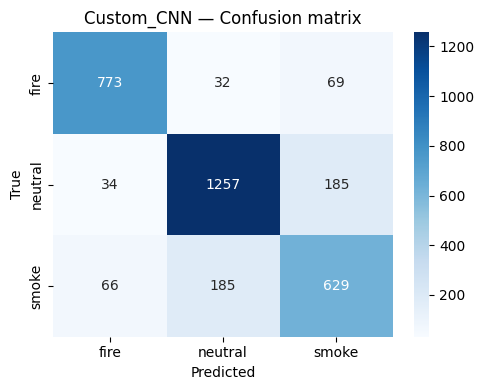


===== MobileNetV2 — Classification report =====
              precision    recall  f1-score   support

        fire      0.773     0.867     0.817       874
     neutral      0.863     0.591     0.701      1476
       smoke      0.574     0.808     0.671       880

    accuracy                          0.725      3230
   macro avg      0.737     0.755     0.730      3230
weighted avg      0.760     0.725     0.725      3230



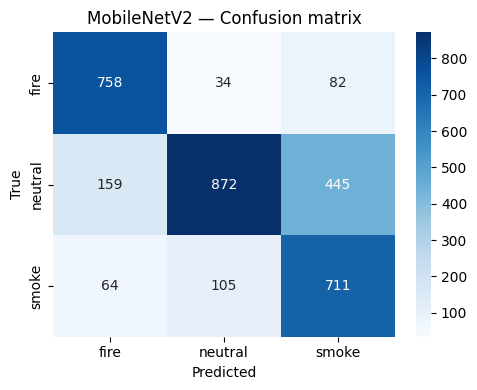

In [12]:
# Gather true labels and predictions for the test set
y_true = np.concatenate([y.numpy() for _, y in test_ds])

def evaluate(model, name):
    probs = model.predict(test_ds, verbose=0)
    y_pred = probs.argmax(axis=1)
    print(f"\n===== {name} — Classification report =====")
    print(classification_report(y_true, y_pred, target_names=CLASSES, digits=3))
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title(f"{name} — Confusion matrix"); plt.xlabel("Predicted"); plt.ylabel("True")
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/cm_{name}.png", dpi=150); plt.show()
    return probs, y_pred

probs_cnn, pred_cnn = evaluate(cnn, "Custom_CNN")
probs_tl,  pred_tl  = evaluate(tl,  "MobileNetV2")

### 9.1 ROC curves (one-vs-rest)

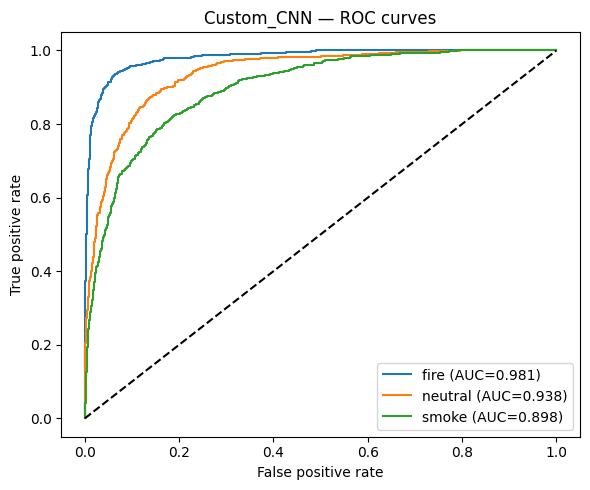

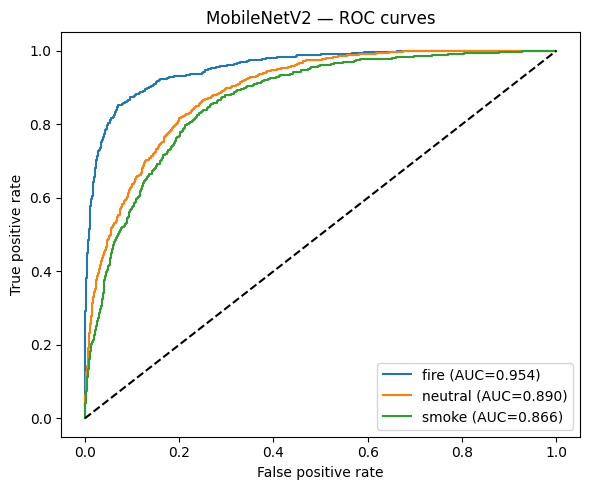

In [13]:
def plot_roc(probs, name):
    y_bin = label_binarize(y_true, classes=range(NUM_CLASSES))
    if NUM_CLASSES == 2:
        y_bin = np.hstack([1 - y_bin, y_bin])
    plt.figure(figsize=(6, 5))
    for i, cls in enumerate(CLASSES):
        fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
        plt.plot(fpr, tpr, label=f"{cls} (AUC={auc(fpr, tpr):.3f})")
    plt.plot([0, 1], [0, 1], "k--")
    plt.title(f"{name} — ROC curves"); plt.xlabel("False positive rate")
    plt.ylabel("True positive rate"); plt.legend()
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/roc_{name}.png", dpi=150); plt.show()

plot_roc(probs_cnn, "Custom_CNN")
plot_roc(probs_tl,  "MobileNetV2")

## 10. Model comparison table

In [14]:
def acc(y_pred): return (y_pred == y_true).mean()
from sklearn.metrics import f1_score, precision_score, recall_score

rows = []
for name, pred in [("Custom CNN", pred_cnn), ("MobileNetV2 (TL)", pred_tl)]:
    rows.append({
        "Model": name,
        "Accuracy":  round(acc(pred), 3),
        "Precision": round(precision_score(y_true, pred, average="macro", zero_division=0), 3),
        "Recall":    round(recall_score(y_true, pred, average="macro", zero_division=0), 3),
        "F1 (macro)":round(f1_score(y_true, pred, average="macro", zero_division=0), 3),
    })
comparison = pd.DataFrame(rows)
comparison.to_csv(f"{OUT_DIR}/model_comparison.csv", index=False)
comparison

,Model,Accuracy,Precision,Recall,F1 (macro)
0,Custom CNN,0.823,0.817,0.817,0.817
1,MobileNetV2 (TL),0.725,0.737,0.755,0.730


## 11. Grad-CAM explainability

Grad-CAM highlights the image regions that most influenced the prediction, giving a
visual sanity check that the model focuses on flames/smoke rather than background.

Using last conv layer: conv2d_3


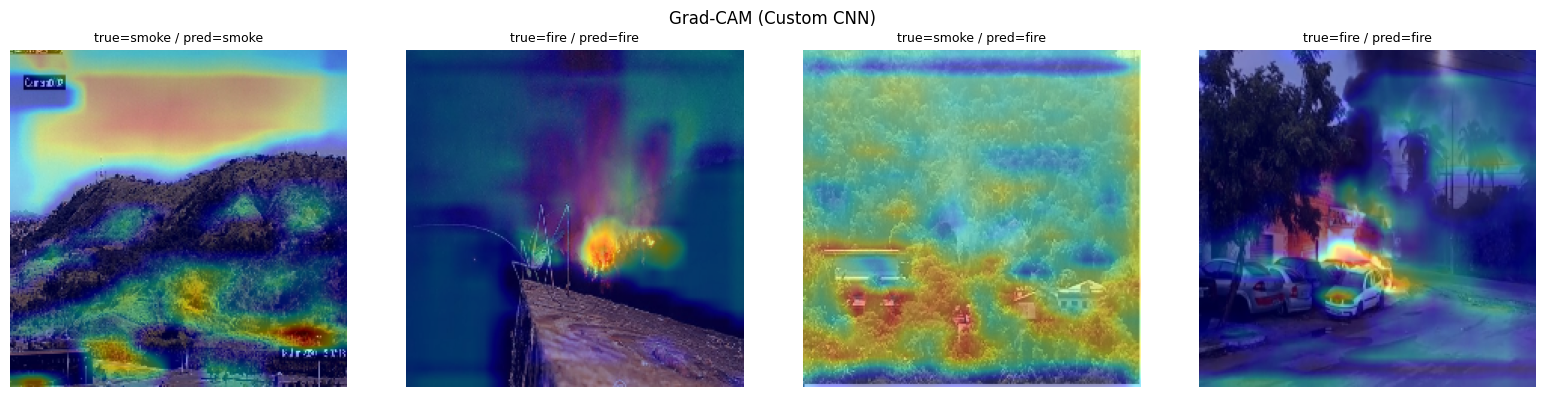

In [15]:
# Grad-CAM explainability - safe version for Sequential Custom CNN

def gradcam_heatmap(img_array, model, last_conv_layer_name):
    with tf.GradientTape() as tape:
        x = img_array
        conv_output = None

        for layer in model.layers:
            x = layer(x)

            if layer.name == last_conv_layer_name:
                conv_output = x
                tape.watch(conv_output)

        preds = x
        class_idx = tf.argmax(preds[0])
        loss = preds[:, class_idx]

    grads = tape.gradient(loss, conv_output)

    if grads is None:
        raise ValueError("Grad-CAM failed because gradients are None. Check last convolution layer name.")

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    heatmap = tf.reduce_sum(conv_output[0] * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy(), CLASSES[int(class_idx)]


# Find last Conv2D layer
last_conv = [l.name for l in cnn.layers if isinstance(l, tf.keras.layers.Conv2D)][-1]
print("Using last conv layer:", last_conv)

samples = test_df.sample(min(4, len(test_df)), random_state=SEED)

fig, axes = plt.subplots(1, len(samples), figsize=(4 * len(samples), 4))
axes = np.atleast_1d(axes)

for ax, (_, row) in zip(axes, samples.iterrows()):
    img, _ = load_image(row["image"], 0)
    arr = tf.expand_dims(img, 0)

    hm, pred_cls = gradcam_heatmap(arr, cnn, last_conv)
    hm = tf.image.resize(hm[..., None], IMG_SIZE).numpy().squeeze()

    ax.imshow(img.numpy())
    ax.imshow(hm, cmap="jet", alpha=0.4)
    ax.set_title(f"true={row['label']} / pred={pred_cls}", fontsize=9)
    ax.axis("off")

plt.suptitle("Grad-CAM (Custom CNN)")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/gradcam.png", dpi=150)
plt.show()

## 12. Save models and confirm outputs

In [16]:
cnn.save(f"{OUT_DIR}/custom_cnn.keras")
tl.save(f"{OUT_DIR}/mobilenetv2_tl.keras")
print("Saved artefacts in", OUT_DIR)
for f in sorted(os.listdir(OUT_DIR)):
    print(" -", f)

Saved artefacts in /kaggle/working/outputs
 - class_distribution.png
 - cm_Custom_CNN.png
 - cm_MobileNetV2.png
 - curves_custom_cnn.png
 - curves_mobilenet.png
 - custom_cnn.keras
 - gradcam.png
 - mobilenetv2_tl.keras
 - model_comparison.csv
 - roc_Custom_CNN.png
 - roc_MobileNetV2.png
 - sample_images.png


# 13. Demonstration – Test Image Prediction

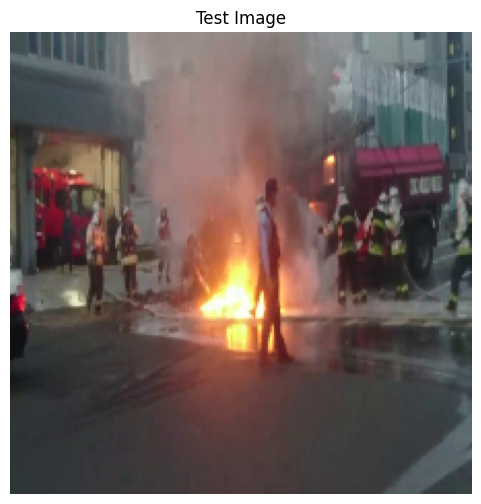

True Class      : fire
Predicted Class : fire
Confidence      : 94.02%


In [17]:
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Load the saved Custom CNN model
model = tf.keras.models.load_model(f"{OUT_DIR}/custom_cnn.keras")

# Select one random image from the test dataset
sample = test_df.sample(1, random_state=random.randint(0,10000)).iloc[0]

image_path = sample["image"]
true_label = sample["label"]

# Load image
img = tf.io.decode_image(tf.io.read_file(image_path),
                         channels=3,
                         expand_animations=False)

img = tf.image.resize(img, IMG_SIZE)
img = tf.cast(img, tf.float32) / 255.0

# Prediction
pred = model.predict(tf.expand_dims(img,0), verbose=0)

pred_index = np.argmax(pred)
pred_label = CLASSES[pred_index]
confidence = np.max(pred) * 100

# Display image
plt.figure(figsize=(6,6))
plt.imshow(img.numpy())
plt.axis("off")
plt.title("Test Image")
plt.show()

print("="*40)
print(f"True Class      : {true_label}")
print(f"Predicted Class : {pred_label}")
print(f"Confidence      : {confidence:.2f}%")
print("="*40)

## 13. Conclusion

The MobileNetV2 transfer-learning model is expected to outperform the custom CNN on
this imbalanced dataset, mainly through stronger recall on the smaller classes, while
the Grad-CAM maps confirm the network attends to flame and smoke regions. Future work
includes fine-tuning the top MobileNetV2 blocks, adding focal loss for imbalance, and
returning to the native YOLO detection task for real-time localisation.